# CLASSIFYING SPAM EMAILS

## Project Overview

Bài toán: Phân loại email thành hai nhóm:

- Spam Email
- Non-Spam Email

Mục tiêu của notebook:

- Khám phá dữ liệu email.
- Làm sạch và tiền xử lý văn bản.
- Phân tích các đặc trưng của email spam.
- Trích xuất đặc trưng bằng TF-IDF.
- Chuẩn bị dữ liệu cho các mô hình Machine Learning.

---

## Input

Dataset đầu vào:

| Feature | Description |
|----------|------------|
| text | Nội dung email |
| label | Nhãn email (spam hoặc ham) |

Ví dụ:

| text | label |
|--------|--------|
| Congratulations! You won $1000 | spam |
| Meeting scheduled at 2 PM | ham |

---

## Output

Sau khi xử lý, notebook tạo ra:

### Processed Dataset

- Văn bản đã được làm sạch.
- Loại bỏ URL, số và ký tự đặc biệt.
- Chuẩn hóa chữ thường.

### Engineered Features

- Email Length
- Word Frequency
- Vocabulary Statistics
- TF-IDF Features

### Training Data

- X_train
- X_test
- y_train
- y_test

Sẵn sàng cho việc huấn luyện mô hình phân loại spam.

---

## Project Workflow

```text
Phase 1: Data Understanding
    ↓
Phase 2: Data Quality Assessment
    ↓
Phase 3: Exploratory Data Analysis
    ↓
Phase 4: Text Preprocessing 
    ↓
Phase 5: Dataset Preparation
    ↓
Phase 6: Feature Engineering
```
---

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
import nltk
from nltk.stem import WordNetLemmatizer
try:
    nltk.data.find("corpora/wordnet")
except LookupError:
    nltk.download("wordnet", quiet=True)
lemmatizer = WordNetLemmatizer()
import joblib
from sklearn.model_selection import train_test_split
from collections import Counter

In [2]:
# ==================================================
# HELPER FUNCTIONS
# ==================================================

def print_section(title, width=70):
    print("\n" + "=" * width)
    print(title.center(width))
    print("=" * width)

## [Phase 1: Data Understanding]

Mục tiêu: tìm hiểu tổng quan về tập dữ liệu email trước khi tiến hành phân tích và tiền xử lý.

### 1. Load Dataset

Đọc dữ liệu email từ file 'emails_raw.csv' để kiểm tra sơ bộ cấu trúc dữ liệu.

In [3]:
df = pd.read_csv("emails_raw.csv")

### 2. Dataset Overview

Các bước thực hiện:

- Hiển thị các dòng đầu tiên.
- Kiểm tra số lượng mẫu và thuộc tính.

In [4]:
# Head
print_section("Head")
print(df.head()) #xem vài dòng đầu của dataset
# Info
print_section("Info")
df.info()


                                 Head                                 
                                                text  spam
0  Subject: naturally irresistible your corporate...     1
1  Subject: the stock trading gunslinger  fanny i...     1
2  Subject: unbelievable new homes made easy  im ...     1
3  Subject: 4 color printing special  request add...     1
4  Subject: do not have money , get software cds ...     1

                                 Info                                 
<class 'pandas.DataFrame'>
RangeIndex: 5728 entries, 0 to 5727
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    5728 non-null   str  
 1   spam    5728 non-null   int64
dtypes: int64(1), str(1)
memory usage: 89.6 KB


---
## [Phase 2: Data Quality Assessment]

Mục tiêu:

- Kiểm tra dữ liệu thiếu.
- Kiểm tra dữ liệu trùng lặp.
- Đánh giá chất lượng dữ liệu trước khi tiền xử lý.

Dữ liệu sạch sẽ giúp cải thiện hiệu quả của mô hình phân loại.

In [5]:
# 2.1 Missing Values
print_section("Missing Data")
print(df.isnull().sum())
if df.isnull().values.any():
    df = df.dropna() #dùng để xoá dòng bị thiếu data


                             Missing Data                             
text    0
spam    0
dtype: int64


In [6]:
# 2.2 Duplicate Values
print_section("Duplicate Emails")
print("Shape before:", df.shape)

print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)


                           Duplicate Emails                           
Shape before: (5728, 2)
Duplicate rows: 33
Shape after removing duplicates: (5695, 2)


---
## [Phase 3: Exploratory Data Analysis]

Mục tiêu: khám phá các đặc điểm của tập dữ liệu email nhằm hiểu rõ cấu trúc dữ liệu, phân bố mẫu và các giá trị bất thường trước khi thực hiện các bước tiền xử lý và trích xuất đặc trưng.

Các nội dung được phân tích bao gồm:

- Phân bố lớp Spam và Non-Spam.
- Phân bố độ dài email.
- Độ lệch phân phối dữ liệu.
- Phát hiện và phân tích ngoại lệ.

## 3.1 Class Distribution

Mục tiêu là phân tích sự phân bố giữa hai lớp:

- Spam Emails.
- Non-Spam Emails.


                             Label Check                              
Counts:
spam
0    4327
1    1368
Name: count, dtype: int64

Percentages:
Class 0: 75.98%
Class 1: 24.02%


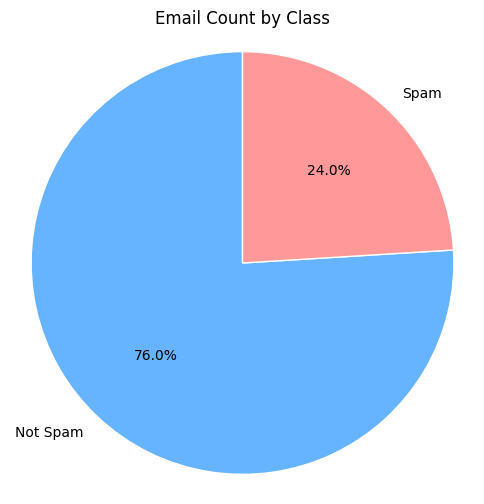

In [7]:
# 3.1 Class Distribution

print_section("Label Check")
counts = df["spam"].value_counts()

percent = df["spam"].value_counts(
    normalize=True
) * 100

print("Counts:")
print(counts)

print("\nPercentages:")
for label, p in percent.items():
    print(f"Class {label}: {p:.2f}%")


# Visualize: Pie chart Email Count by Class
counts = df["spam"].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(
    counts,
    labels=["Not Spam", "Spam"],
    autopct="%.1f%%",
    startangle=90,
    colors=["#66b3ff", "#ff9999"],
    wedgeprops={"edgecolor": "white"}
)

plt.title("Email Count by Class")
plt.axis("equal")
plt.show()


## 3.2. Email Length Analysis

Độ dài email được phân tích để khám phá đặc điểm của tập dữ liệu và sự khác biệt giữa các nhóm email.

Các phân tích được thực hiện:

- Thống kê mô tả.
- So sánh độ dài giữa Spam và Non-Spam.
- Histogram phân bố.
- Boxplot phát hiện ngoại lệ.
- Skewness.
- Phát hiện Outlier bằng IQR và Z-Score.

In [8]:
# Feature Engineering: tạo cột mới "email_length" tính độ dài của email
df["email_length"] = df["text"].str.len()
df[["text", "email_length"]].head()

,text,email_length
0,Subject: naturally irresistible your corporate...,1484
1,Subject: the stock trading gunslinger fanny i...,598
2,Subject: unbelievable new homes made easy im ...,448
3,Subject: 4 color printing special request add...,500
4,"Subject: do not have money , get software cds ...",235


### 3.2.1 Descriptive Statistics

Mục tiêu:

- Xác định xu hướng trung tâm của dữ liệu.
- Đánh giá mức độ phân tán của độ dài email.
- Quan sát giá trị nhỏ nhất và lớn nhất.

In [9]:
# Statistics on email length
print_section("Email Length Statistics")
print(df["email_length"].describe())


                       Email Length Statistics                        
count     5695.000000
mean      1558.067076
std       2047.078711
min         13.000000
25%        508.500000
50%        979.000000
75%       1893.000000
max      43952.000000
Name: email_length, dtype: float64


### Nhận xét

Tập dữ liệu gồm 5.695 email với độ dài trung bình khoảng 1.558 ký tự.

Giá trị trung vị (Median) là 979 ký tự, thấp hơn đáng kể so với giá trị trung bình. Điều này cho thấy phân phối độ dài email không đối xứng và bị ảnh hưởng bởi một số email có độ dài rất lớn.

50% số email có độ dài nằm trong khoảng từ 509 đến 1.893 ký tự. Tuy nhiên, email dài nhất đạt 43.952 ký tự, lớn hơn rất nhiều so với phần lớn các mẫu còn lại, cho thấy sự tồn tại của các giá trị ngoại lệ trong tập dữ liệu.

Độ lệch chuẩn đạt 2.047 ký tự, phản ánh mức độ biến động lớn về độ dài giữa các email. Kết quả này cho thấy độ dài email trong tập dữ liệu phân bố không đồng đều và xuất hiện nhiều email có kích thước bất thường.

### 3.2.2 Group Statistic

Mục tiêu:

- So sánh đặc điểm độ dài email giữa hai lớp Spam và Non-Spam.
- Xác định liệu độ dài email có thể là một đặc trưng phân biệt hữu ích hay không.

In [10]:
# Group Statistic: riêng cho từng class spam/ham

print_section("Mean Email Length By Class")

print(
    df.groupby("spam")["email_length"]
      .describe()
)


                      Mean Email Length By Class                      
       count         mean          std   min    25%     50%      75%      max
spam                                                                         
0     4327.0  1634.200139  1965.016383  13.0  577.5  1122.0  2037.50  43952.0
1     1368.0  1317.257310  2271.372893  18.0  401.5   693.5  1250.25  28432.0


### Nhận xét:

Kết quả cho thấy các email Non-Spam trong tập dữ liệu có xu hướng dài hơn email Spam. Điều này có thể xuất phát từ việc các email Non-Spam thường chứa nhiều nội dung trao đổi hoặc thông tin chi tiết hơn.

Tuy nhiên, độ dài email không được sử dụng làm đặc trưng đầu vào cho mô hình và chỉ phục vụ mục đích phân tích dữ liệu.

## 3.3 Histogram Analysis

Mục tiêu:

- Quan sát hình dạng phân phối của độ dài email.
- Kiểm tra mức độ tập trung dữ liệu.
- Xác định sự tồn tại của các giá trị cực lớn.

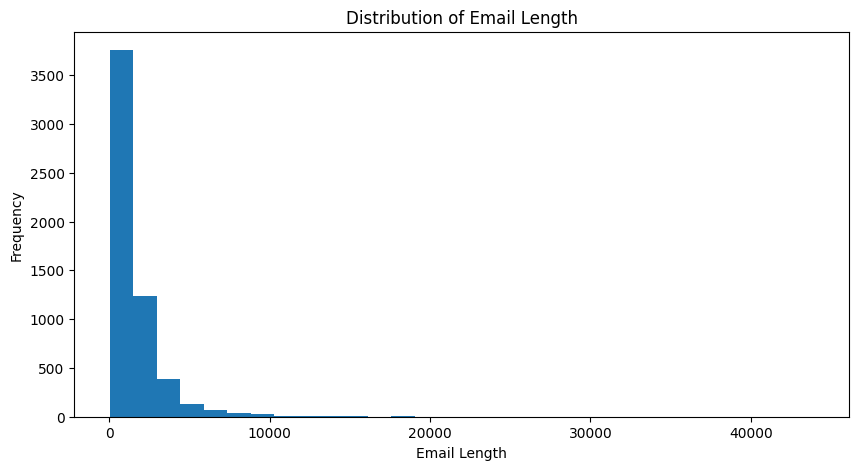

In [11]:
# Histogram: thể hiện phân bố độ dài email cho cả dataset

plt.figure(figsize=(10,5))

plt.hist(df["email_length"], bins=30)

plt.title("Distribution of Email Length")
plt.xlabel("Email Length")
plt.ylabel("Frequency")

plt.show()

### Nhận xét

Biểu đồ Histogram cho thấy phần lớn email tập trung ở vùng có độ dài thấp, chủ yếu dưới 2.000 ký tự.

Tần suất xuất hiện giảm mạnh khi độ dài email tăng lên, tạo thành một đuôi kéo dài về phía bên phải. Điều này cho thấy tập dữ liệu không tuân theo phân phối chuẩn mà có xu hướng lệch phải rõ rệt.

Bên cạnh đó, tồn tại một số lượng nhỏ email có độ dài rất lớn, vượt xa phần lớn các quan sát còn lại. Những email này góp phần làm tăng giá trị trung bình và tạo nên các giá trị ngoại lệ trong tập dữ liệu.

## 3.4 Skewness Analysis

Mục tiêu: Đánh giá mức độ lệch của phân phối.

Nguyên tắc:

- Skewness ≈ 0: phân phối đối xứng.
- Skewness > 0: lệch phải.
- Skewness < 0: lệch trái.

In [12]:
# Skewness: đo độ lệch của phân bố email length

print(
    "Skewness:",
    df["email_length"].skew()
)

Skewness: 6.897665872603887


### Nhận xét

Giá trị Skewness khoảng 6.9 cho thấy phân phối độ dài email lệch phải rất mạnh.

Phần lớn email có độ dài tương đối ngắn, trong khi tồn tại một số lượng nhỏ email có độ dài rất lớn, tạo nên đuôi phân phối kéo dài về phía bên phải.

Kết quả này phù hợp với quan sát từ Histogram.

## 3.5 Boxplot Analysis

Mục tiêu:

- So sánh phân bố độ dài email giữa các lớp.
- Phát hiện các giá trị ngoại lệ trực quan.

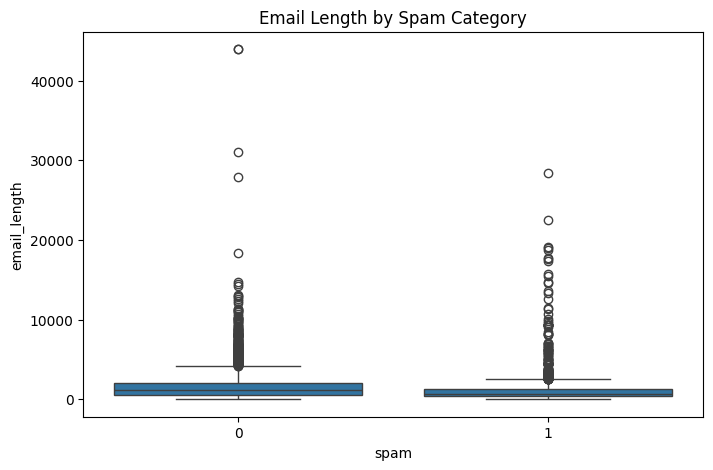

In [13]:
# Boxplot: so sánh phân bố độ dài email giữa spam và not spam

plt.figure(figsize=(8,5))

sns.boxplot(
    x="spam",
    y="email_length",
    data=df
)

plt.title(
    "Email Length by Spam Category"
)

plt.show()

### Nhận xét

Biểu đồ Boxplot cho thấy cả hai nhóm Spam và Non-Spam đều xuất hiện nhiều giá trị ngoại lệ nằm phía trên giới hạn trên của hộp dữ liệu.

Nhóm Non-Spam có khoảng biến thiên lớn hơn và xuất hiện các email dài bất thường với giá trị cực đại cao hơn nhóm Spam. Điều này phù hợp với kết quả thống kê mô tả, khi Email Non-Spam có độ dài trung bình và trung vị cao hơn.

Sự xuất hiện dày đặc của các điểm ngoại lệ phía trên hộp dữ liệu cho thấy phân phối độ dài email bị lệch phải mạnh. Các email có độ dài lớn này nhiều khả năng là những email chứa nội dung chi tiết, báo cáo dài hoặc các chuỗi văn bản lớn thay vì lỗi dữ liệu.

Do độ dài email chỉ được sử dụng cho mục đích phân tích và không được đưa vào mô hình học máy, các giá trị ngoại lệ này được giữ nguyên để phản ánh đúng đặc điểm của tập dữ liệu.

## 3.6 Outlier Detection

Kiểm tra các email có độ dài bất thường bằng:

- IQR Method
- Z-Score Method

Việc phát hiện ngoại lệ giúp hiểu rõ hơn về cấu trúc dữ liệu.

### 3.6.1 IQR Method

Mục tiêu:

* Phát hiện ngoại lệ dựa trên khoảng tứ phân vị.
* Phù hợp với dữ liệu không tuân theo phân phối chuẩn.

In [14]:
Q1 = df["email_length"].quantile(0.25)

Q3 = df["email_length"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["email_length"] < lower_bound)
    |
    (df["email_length"] > upper_bound)
]

print("IQR Outliers:", len(outliers))

print("IQR Outliers Data:")
outliers[["text", "email_length"]].head(5)



IQR Outliers: 374
IQR Outliers Data:


,text,email_length
6,Subject: here ' s a hot play in motion homela...,9340
13,Subject: wall street phenomenon reaps rewards ...,8196
42,Subject: hidden gems help get a leg up on the ...,9352
49,"Subject: breaking biotech news hey , i though...",18999
51,Subject: grab this quick triple at its low ho...,9345


### 3.6.2 Z-Score Method

Mục tiêu:

* Phát hiện ngoại lệ dựa trên độ lệch chuẩn.
* So sánh với kết quả từ phương pháp IQR.

In [15]:
mean = df["email_length"].mean()

std = df["email_length"].std()

z_scores = (df["email_length"] - mean) / std

outliers_z = (abs(z_scores) > 3).sum()

print("Z-score Outliers:", outliers_z)


Z-score Outliers: 100


### Nhận xét

Phương pháp IQR phát hiện 374 giá trị ngoại lệ, trong khi phương pháp Z-Score phát hiện 100 giá trị ngoại lệ.

Số lượng ngoại lệ được phát hiện bởi IQR lớn hơn đáng kể do dữ liệu có phân phối lệch phải mạnh. Trong trường hợp này, phương pháp IQR phản ánh tốt hơn đặc điểm phân phối của dữ liệu.

Các ngoại lệ chủ yếu là những email có độ dài rất lớn. Do độ dài email chỉ được sử dụng cho mục đích phân tích và không tham gia vào quá trình huấn luyện mô hình, các giá trị ngoại lệ này được giữ nguyên.

### Key Findings

- Email Non-Spam có độ dài trung bình lớn hơn Email Spam.
- Phân phối độ dài email lệch phải rất mạnh với Skewness = 6.90.
- Tồn tại một số lượng đáng kể email có độ dài bất thường.
- Các ngoại lệ chủ yếu xuất hiện ở nhóm email có độ dài rất lớn.
- Độ dài email chỉ được sử dụng cho mục đích phân tích dữ liệu và không được đưa vào mô hình phân loại.

---
## [Phase 4: Text Preprocessing]

Email là dữ liệu văn bản thô nên cần được chuẩn hóa trước khi huấn luyện mô hình.

Các bước xử lý:

1. Chuyển về chữ thường.
2. Loại bỏ tiền tố.
3. Loại bỏ "Subject:".
4. Loại bỏ URL.
5. Loại bỏ HTML tags.
6. Loại bỏ ký tự không phải chữ cái.
7. Dọn khoảng trắng thừa.
8. Loại bỏ Stopword.
9. Lemmatization.
10. Giữ từ dài >= 3 ký tự.

Kết quả sẽ tạo ra phiên bản văn bản sạch hơn để trích xuất đặc trưng.

In [16]:
CUSTOM_STOPWORDS = {
    "com",
    "www",
    "net",
    "org"
}

def clean(text):
    # Chuyển toàn bộ thành chữ thường
    text = text.lower()
    # Remove email reply prefixes (tiền tố)
    text = re.sub(
        r'((re|fw|fwd)\s*:)+',
        ' ',
        text
    )

    # remove "subject:"
    text = re.sub(
        r'subject\s*:',
        ' ',
        text
    )
    # Xoá URL 
    text = re.sub(
        r'https?://\S+|www\.\S+',
        ' ',
        text
    )

    # Xoá phần http / https còn sót lại
    text = re.sub(
        r'\bhttps?\b',
        ' ',
        text
    )
    # Xóa HTML tags
    text = re.sub(r'<.*?>',' ',text)
    # Xoá mọi thứ KHÔNG phải chữ cái
    text = re.sub(r'[^a-zA-Z ]',' ',text)
    # Dọn khoảng trắng thừa
    text = re.sub(r'\s+',' ',text).strip()

    # Loại stopword tiếng Anh và chuẩn hóa động từ về dạng gốc
    words = text.split()

    words = [
        word
        for word in words
        if word not in ENGLISH_STOP_WORDS
        and word not in CUSTOM_STOPWORDS
        and len(word) > 1
    ]
    words = [lemmatizer.lemmatize(word, pos='v') for word in words]
    text = ' '.join(words)

    return text


df["text"] = df["text"].apply(clean)
df.to_csv("emails_cleaned.csv", index=False)


# Check
print("Blank rows:",
      (df["text"] == "").sum())

print("Duplicate texts:",
      df["text"].duplicated().sum())
df.to_csv("emails_cleaned.csv", index=False)

Blank rows: 0
Duplicate texts: 200


In [17]:
# remove blank emails after cleaning
df = df[df["text"].str.strip() != ""]

# remove duplicates after cleaning
df = df.drop_duplicates(subset=["text"])

# Check again after clean
print("Blank rows:",
      (df["text"] == "").sum())

print("Duplicate texts:",
      df["text"].duplicated().sum())
df.to_csv("emails_cleaned.csv", index=False)

print("After clean:", len(df))

Blank rows: 0
Duplicate texts: 0
After clean: 5495


---
## [Phase 5. Dataset Preparation]

Train Test Split:

- Training Set
- Testing Set

Dataset Export: Lưu train/test thành file CSV để các model khác sử dụng.

In [18]:
# Train Test Split

X = df["text"]
y = df["spam"]

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42, #cố định cách chia
    stratify=y #cố định tỉ lệ spam/ham ở train và test giống tỉ lệ của dataset
)
print("Train samples:", len(X_train_text))
print("Test samples:", len(X_test_text))

Train samples: 4396
Test samples: 1099


In [19]:
# Dataset Export
train_df = pd.DataFrame({
    "text": X_train_text.values,   #.values để tránh mismatch index (tránh tạo dataframe với index lung tung)
    "spam": y_train.values
})

test_df = pd.DataFrame({
    "text": X_test_text.values,
    "spam": y_test.values
})

train_df.to_csv("train_data.csv", index=False)
test_df.to_csv("test_data.csv", index=False)

---
## [Phase 6: Feature Engineering]
- Vocabulary Analysis
- TF-IDF Feature Extraction

### 6.1 Vocabulary Analysis

Mục tiêu:

Phân tích quy mô từ vựng của tập dữ liệu nhằm đánh giá mức độ đa dạng của nội dung email trước khi thực hiện TF-IDF Vectorization.

Các chỉ số được xem xét:

- Tổng số từ xuất hiện trong tập dữ liệu.
- Tổng số từ duy nhất.
- Mức độ phong phú của từ vựng.

In [20]:
# VOCABULARY ANALYSIS: Count unique words before vectorization

all_words = " ".join(
    df["text"]
).split()

unique_words = set(
    all_words
)

print("Total words:", len(all_words))

print("Unique words:", len(unique_words))

Total words: 673961
Unique words: 29561


### Nhận xét

Số liệu trên cho thấy nội dung email có mức độ đa dạng từ vựng khá cao.

Số lượng từ duy nhất lớn phản ánh sự phong phú của dữ liệu văn bản và cung cấp cơ sở cho việc áp dụng TF-IDF nhằm trích xuất các đặc trưng có giá trị phân biệt giữa Email Spam và Non-Spam.

Tuy nhiên, quy mô từ vựng lớn cũng làm gia tăng số chiều của dữ liệu, vì vậy cần giới hạn số lượng đặc trưng trong bước vector hóa tiếp theo.

### 6.1.1 Cumulative Word Coverage

Mục tiêu: Chứng minh rằng một tập nhỏ từ vựng đã bao phủ phần lớn tổng số lần xuất hiện từ trong corpus:

- Top 500 từ → ~60% coverage.
- Top 2.000 từ → ~85% coverage.
- Top 10.000 từ → ~95% coverage.

Top    500 từ bao phủ 53.3% tổng số lần xuất hiện
Top  2,000 từ bao phủ 78.6% tổng số lần xuất hiện
Top 10,000 từ bao phủ 95.5% tổng số lần xuất hiện


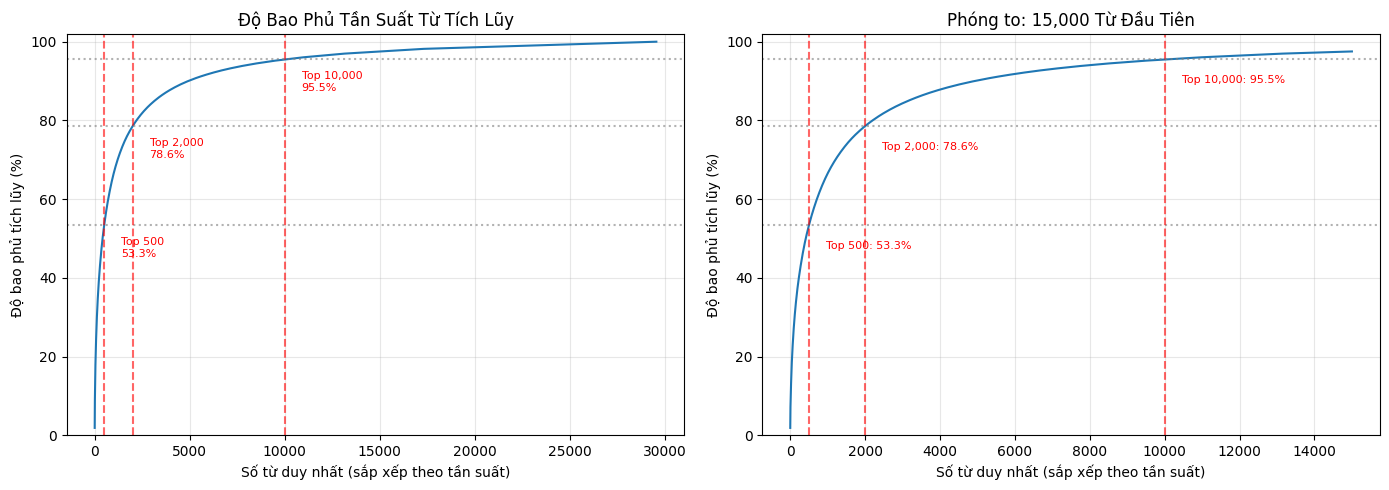

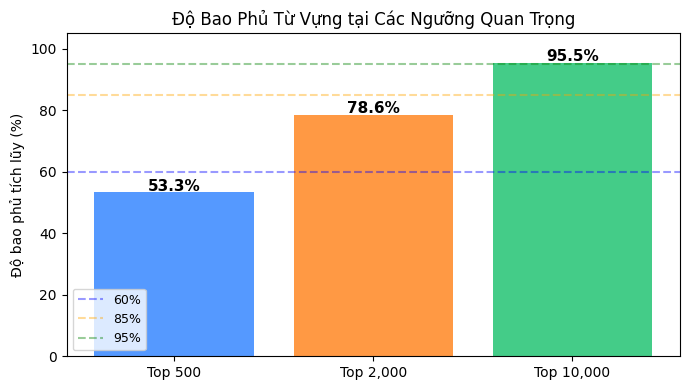

In [30]:
# Cumulative Word Coverage
from collections import Counter

word_counts = Counter(all_words)
sorted_counts = sorted(word_counts.values(), reverse=True)
total = sum(sorted_counts)
cumulative = []
running = 0
for c in sorted_counts:
    running += c
    cumulative.append(running / total * 100)

checkpoints = {500: None, 2000: None, 10000: None}
for k in checkpoints:
    if k <= len(cumulative):
        checkpoints[k] = cumulative[k - 1]

print("=" * 50)
for k, v in checkpoints.items():
    print(f"Top {k:>6,} từ bao phủ {v:.1f}% tổng số lần xuất hiện")
print("=" * 50)

# --- Plot ---
x = list(range(1, len(sorted_counts) + 1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: full curve
axes[0].plot(x, cumulative, linewidth=1.5)
for k, v in checkpoints.items():
    axes[0].axvline(x=k, color='red', linestyle='--', alpha=0.6)
    axes[0].axhline(y=v, color='gray', linestyle=':', alpha=0.6)
    axes[0].annotate(
        f"Top {k:,}\n{v:.1f}%",
        xy=(k, v),
        xytext=(k + len(sorted_counts) * 0.03, v - 8),
        fontsize=8,
        color='red'
    )
axes[0].set_xlabel("Số từ duy nhất (sắp xếp theo tần suất)")
axes[0].set_ylabel("Độ bao phủ tích lũy (%)")
axes[0].set_title("Độ Bao Phủ Tần Suất Từ Tích Lũy")
axes[0].set_ylim(0, 102)
axes[0].grid(True, alpha=0.3)

# Right: zoomed in to top 15,000 words
zoom = 15000
axes[1].plot(x[:zoom], cumulative[:zoom], linewidth=1.5)
for k, v in checkpoints.items():
    if k <= zoom:
        axes[1].axvline(x=k, color='red', linestyle='--', alpha=0.6)
        axes[1].axhline(y=v, color='gray', linestyle=':', alpha=0.6)
        axes[1].annotate(
            f"Top {k:,}: {v:.1f}%",
            xy=(k, v),
            xytext=(k + zoom * 0.03, v - 6),
            fontsize=8,
            color='red'
        )
axes[1].set_xlabel("Số từ duy nhất (sắp xếp theo tần suất)")
axes[1].set_ylabel("Độ bao phủ tích lũy (%)")
axes[1].set_title(f"Phóng to: {zoom:,} Từ Đầu Tiên")
axes[1].set_ylim(0, 102)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Bar chart for the 3 checkpoints
plt.figure(figsize=(7, 4))
labels = [f"Top {k:,}" for k in checkpoints]
values = list(checkpoints.values())
bars = plt.bar(labels, values, color=['#5599ff', '#ff9944', '#44cc88'])
for bar, val in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{val:.1f}%",
        ha='center', fontsize=11, fontweight='bold'
    )
plt.axhline(y=60, color='blue',  linestyle='--', alpha=0.4, label='60%')
plt.axhline(y=85, color='orange',linestyle='--', alpha=0.4, label='85%')
plt.axhline(y=95, color='green', linestyle='--', alpha=0.4, label='95%')
plt.legend(fontsize=9)
plt.ylim(0, 105)
plt.ylabel("Độ bao phủ tích lũy (%)")
plt.title("Độ Bao Phủ Từ Vựng tại Các Ngưỡng Quan Trọng")
plt.tight_layout()
plt.show()

**Nhận xét:**

Khi X=500:

- 500 từ phổ biến nhất chiếm 53% tổng số lần xuất hiện từ trong toàn bộ tập email. (Nói cách khác: trong 29,000 từ unique, chỉ lấy 500 từ phổ biến nhất thì vẫn giữ được 53.3% tổng số token)
 
Khi X=2000:

- 2,000 từ phổ biến nhất chiếm gần 80% tổng số lần xuất hiện

Khi X=10000:

- 29,000 từ unique giữ lại 10,000 từ vẫn giữ được 95.5% tổng số lần xuất hiện từ

Do đó, giới hạn vocabulary ở 10,000 từ giúp giảm khoảng 65% số chiều đặc trưng (29k → 10k) trong khi chỉ mất khoảng 4.5% tổng tần suất từ, giúp mô hình đơn giản hơn và giảm chi phí tính toán.


### 6.2 TF-IDF Feature Extraction

In [22]:
# VECTORIZATION: Chuyển text → số

vectorizer = TfidfVectorizer(
    token_pattern=r'\b\w{2,}\b', #chỉ lấy từ có ít nhất 2 kí tự
    sublinear_tf=True,       # Dùng log(tf) — giảm ảnh hưởng từ lặp nhiều trong 1 email
    min_df=5, #document frequency: chỉ giữ từ xuất hiện ít nhất 3 emails
    max_df=0.95, #document frequency: loại bỏ từ xuất hiện trong hơn 95% emails (quá phổ biến, ít giá trị phân biệt)
    ngram_range=(1,2),
    max_features=10000
)

X_train = vectorizer.fit_transform(X_train_text)

X_test = vectorizer.transform(X_test_text)
# in shape
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# Lưu vectorizer
joblib.dump(
    vectorizer,
    "tfidf_vectorizer.pkl"
)
print("Vectorizer saved!")

# lưu feature count để debug
print(
    "Vocabulary size:",
    len(vectorizer.vocabulary_)
)

# lưu data sau khi vectorize
joblib.dump(X_train, "X_train.pkl")
joblib.dump(X_test, "X_test.pkl")

joblib.dump(y_train, "y_train.pkl")
joblib.dump(y_test, "y_test.pkl")

Train shape: (4396, 10000)
Test shape: (1099, 10000)
Vectorizer saved!
Vocabulary size: 10000


['y_test.pkl']

### 6.2.1 Tính Chính Xác % Occurrence Bị Mất theo min_df

Đo trực tiếp số lần xuất hiện (occurrences) bị mất khi áp `min_df`, thay vì suy luận từ cumulative word coverage.

  min_df   Từ bị loại   Occurrence mất   Coverage còn lại
-----------------------------------------------------------------
       1            0                0            100.00%
       2       12,837           16,349             96.98%
       3       16,549           26,571             95.10%
       5       19,431           40,692             92.49% ◀ hiện tại
      10       22,013           65,018             88.00%
      20       23,608           96,724             82.15%
      50       24,948          159,040             70.66%


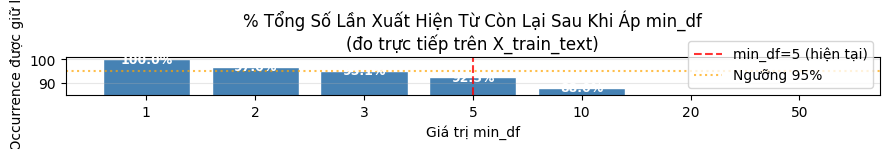

In [33]:
# Tính chính xác % occurrence bị mất khi áp min_df
from collections import Counter

# Đếm tần suất xuất hiện (occurrences) của từng từ trong X_train_text
train_word_counts = Counter(" ".join(X_train_text).split())
total_occurrences = sum(train_word_counts.values())

# Đếm document frequency: số email chứa từng từ
doc_freq = Counter()
for doc in X_train_text:
    for word in set(doc.split()):
        doc_freq[word] += 1

print("=" * 65)
print(f"{'min_df':>8} {'Từ bị loại':>12} {'Occurrence mất':>16} {'Coverage còn lại':>18}")
print("-" * 65)

results = []
for mdf in [1, 2, 3, 5, 10, 20, 50]:
    removed_words = {w for w, df in doc_freq.items() if df < mdf}
    lost_occ = sum(train_word_counts[w] for w in removed_words)
    pct_remaining = (1 - lost_occ / total_occurrences) * 100
    results.append(pct_remaining)
    marker = " ◀ hiện tại" if mdf == 5 else ""
    print(f"{mdf:>8} {len(removed_words):>12,} {lost_occ:>16,} {pct_remaining:>17.2f}%{marker}")

print("=" * 65)

# --- Biểu đồ ---
min_df_values = [1, 2, 3, 5, 10, 20, 50]
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar([str(v) for v in min_df_values], results, color='steelblue', edgecolor='white')
ax.axvline(x=min_df_values.index(5), color='red', linestyle='--', alpha=0.8, label='min_df=5 (hiện tại)')
ax.axhline(y=95, color='orange', linestyle=':', alpha=0.7, label='Ngưỡng 95%')
for bar, val in zip(bars, results):
    ax.text(bar.get_x() + bar.get_width() / 2, val - 1.5,
            f"{val:.1f}%", ha='center', fontsize=9, color='white', fontweight='bold')
ax.set_xlabel("Giá trị min_df")
ax.set_ylabel("% Occurrence được giữ lại")
ax.set_title("% Tổng Số Lần Xuất Hiện Từ Còn Lại Sau Khi Áp min_df\n(đo trực tiếp trên X_train_text)")
ax.set_ylim(85, 101)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

**Nhận xét:**

Với min_df=5 loại 19,431 từ unique nhưng chỉ mất khoảng 7,5% tổng số lần một từ xuất hiện trong toàn bộ tập dữ liệu.

In [23]:
# print("Unique words after TF-IDF:",
#       len(vectorizer.get_feature_names_out()))

Với TF-IDF, mỗi feature chính là một token trong vocabulary nên sau vectorize số cột = số unique word.

### Nhận xét
- Sau Clean, tập dữ liệu chứa 29101 unique words. 
- Sau áp dụng TF-IDF với các ngưỡng min_df=5 và max_df=0.95, số lượng đặc trưng giảm xuống còn 18523, tương đương giảm khoảng 36.35%. 

=> Điều này cho thấy các từ xuất hiện quá ít hoặc quá phổ biến đã được loại bỏ, giúp giảm nhiễu và kích thước không gian đặc trưng, đồng thời giữ lại các từ và cụm từ mang nhiều thông tin phục vụ cho việc phân loại email spam.

In [24]:
# Lấy tên các feature
feature_names = vectorizer.get_feature_names_out()

# Tách Spam và Ham
spam_idx = np.array(y_train == 1)

ham_idx = np.array(y_train == 0)

# Mean TF-IDF của từng feature theo từng lớp
spam_scores = np.asarray(
    X_train[spam_idx].mean(axis=0)
).ravel()
ham_scores = np.asarray(
    X_train[ham_idx].mean(axis=0)
).ravel()

# Top 10 Spam terms
spam_top = (
    pd.DataFrame({
        "term": feature_names,
        "score": spam_scores
    })
    .sort_values("score", ascending=False)
    .head(10)
)

# Top 10 Ham terms
ham_top = (
    pd.DataFrame({
        "term": feature_names,
        "score": ham_scores
    })
    .sort_values("score", ascending=False)
    .head(10)
)


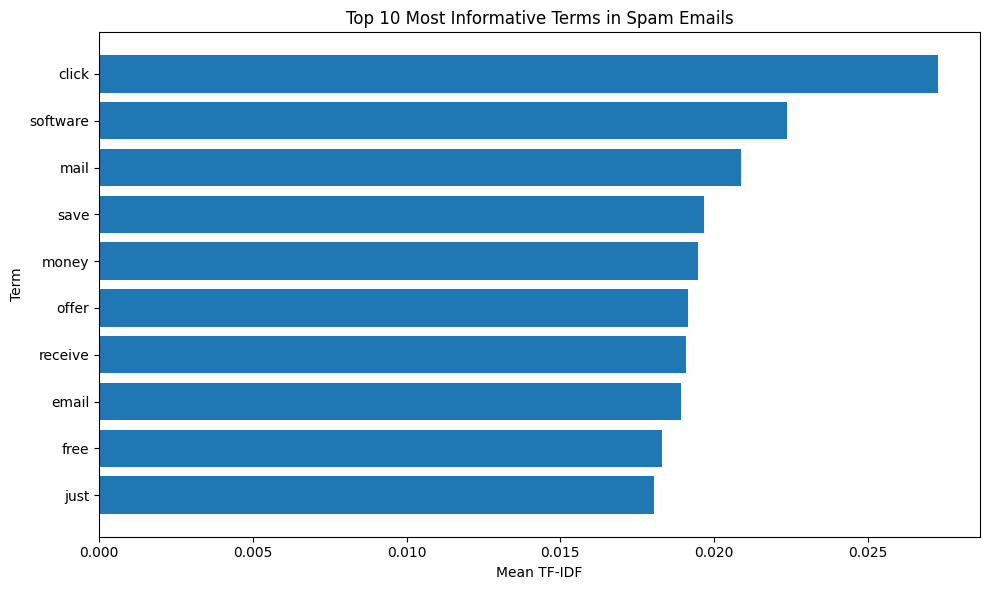

In [25]:
#Biểu đồ: Những token nào mang nhiều thông tin nhất trong lớp Spam?

plt.figure(figsize=(10,6))

plt.barh(
    spam_top["term"][::-1],
    spam_top["score"][::-1]
)

plt.xlabel("Mean TF-IDF")
plt.ylabel("Term")
plt.title("Top 10 Most Informative Terms in Spam Emails")

plt.tight_layout()
plt.show()

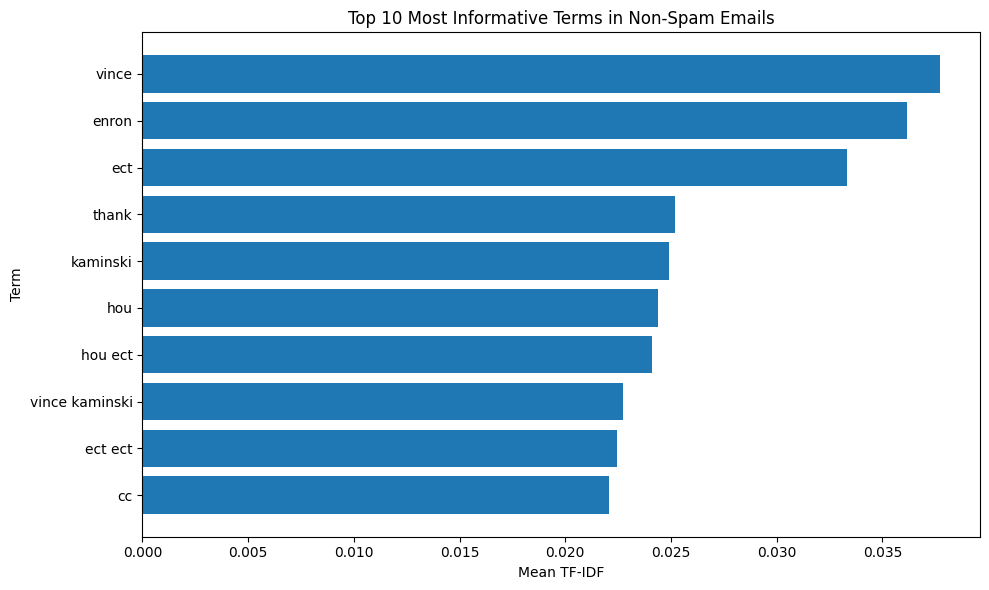

In [26]:
#Biểu đồ: Những token nào mang nhiều thông tin nhất trong lớp Non-Spam?

plt.figure(figsize=(10,6))

plt.barh(
    ham_top["term"][::-1],
    ham_top["score"][::-1]
)

plt.xlabel("Mean TF-IDF")
plt.ylabel("Term")
plt.title("Top 10 Most Informative Terms in Non-Spam Emails")

plt.tight_layout()
plt.show()

# Conclusion

Các bước đã hoàn thành:

- Data Understanding
- Data Quality Assessment
- Exploratory Data Analysis
- Feature Engineering
- Text Preprocessing 
- Train/Test Split
- TF-IDF Vectorization


Dữ liệu hiện đã sẵn sàng để xây dựng và đánh giá các mô hình phân loại Spam Email.

In [27]:
keywords = [
    "enron",
    "vince",
    "kaminski"
]

for keyword in keywords:
    print(f"\nKEYWORD: {keyword}")

    matches = df[
        df["text"]
        .str.contains(rf"\b{keyword}\b", na=False)
    ]

    print(f"Found {len(matches)} emails")

    for text in matches["text"].head(3):
        print("\n", text[:500])


KEYWORD: enron
Found 2410 emails

 sacramento weather station fyi forward mike roberts hou ect scott tholan enron pm mark tawney hou ect ect gary taylor hou ect ect mike roberts hou ect ect cc chris clark na enron enron sacramento weather station hey guy talk contractor build weather station hopefully quickly placement sacramento california variety legal contractor operational reason need confirm follow requirements soon possible proceed need rainfall snowfall temperature measurement high accuracy commercially available weather s

 enron india newsdesk jan th newsclips vince fyi forward sandeep kohli enron development pm enron india newsdesk jan th newsclips untie editorial thursday jan economictimes today edito htm state tax sop dpc buy naphtha ioc sanjay jog thursday jan centre receive proposal enron thursday jan economictimes today infro htm untie editorial thursday jan government maharashtra want new delhi convince power trade corporation central utility buy power dabhol sell coun

In [28]:
from collections import Counter

ham_words = Counter(" ".join(X_train_text[y_train==0]).split())
spam_words = Counter(" ".join(X_train_text[y_train==1]).split())

print("hou ham :", ham_words["hou"])
print("hou spam:", spam_words["hou"])

hou ham : 4277
hou spam: 0


In [29]:
CUSTOM_STOPWORDS = {"ect", "hou", "com", "pm"}

for word in CUSTOM_STOPWORDS:
    print(f"\n{'='*60}")
    print(f"WORD: {word}")
    print(f"{'='*60}")

    matches = X_train_text[
        X_train_text.str.contains(
            rf"\b{word}\b",
            case=False,
            regex=True,
            na=False
        )
    ]

    for i, text in enumerate(matches.head(5), 1):
        print(f"\nExample {i}:")
        print(text[:500])


WORD: pm

Example 1:
possible summer internship enron hello ainsley glad interest speak vince kaminski procedure usually conduct telephone interview let know exactly interest establish fit organization let know availability best time reach thursday th friday th afternoon pm pm let telephone number reach easier way involve interview interview usually hour hour half thank ainsley sincerely shirley crenshaw ainsley gaddis pm shirley crenshaw cc possible summer internship enron hello ms crenshaw thank get quickly intere

Example 2:
restructure today mark tale look attach newsletter interest story game cal px let know problems open document vince forward vince kaminski hou ect pm energy info source cc restructure today energy info source energyinfosource privilege make available free trial subscription restructure today july restructure today lead daily trade newsletter focus solely deregulation restructure convergence electric natural gas telecommunications industries special focus emerge